# 🎓 EduScope: Student Performance & Placement Analytics

## 📌 Project Overview

This project analyzes the academic performance and placement trends of engineering students using Python.

The analysis focuses on identifying patterns related to attendance, study habits, internships, projects, certifications, and placement outcomes through Exploratory Data Analysis (EDA).

---

## 🎯 Objectives

- Analyze student academic performance
- Study placement trends
- Identify factors affecting CGPA
- Analyze salary distribution
- Draw meaningful business insights

---

## 🛠️ Technologies Used

- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Google Colab

In [5]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

# Display plots inside the notebook
%matplotlib inline

# Better looking plots
plt.style.use("ggplot")

# Ensures we get the same random data every time
np.random.seed(42)

# Number of students
n = 5000

# Categories
branches = ["CSE", "IT", "ECE", "Mechanical", "Civil"]
genders = ["Male", "Female"]
years = [1, 2, 3, 4]

print("Setup completed successfully!")

Setup completed successfully!


# 📂 Dataset Generation

A synthetic dataset containing information for 5,000 engineering students was generated using NumPy and Pandas.

The dataset includes demographic details, academic performance, study habits, internships, projects, certifications, placement status, company tier, and salary information.

In [6]:
# Create an empty DataFrame
df = pd.DataFrame()

# Generate basic student information
df["Student_ID"] = [f"STU{str(i).zfill(4)}" for i in range(1, n + 1)]

df["Gender"] = np.random.choice(
    genders,
    size=n,
    p=[0.55, 0.45]
)

df["Age"] = np.random.randint(18, 24, size=n)

df["Branch"] = np.random.choice(
    branches,
    size=n,
    p=[0.30, 0.20, 0.20, 0.15, 0.15]
)

df["Year"] = np.random.choice(years, size=n)

# Display the first 5 rows
df.head()

,Student_ID,Gender,Age,Branch,Year
0,STU0001,Male,20,CSE,2
1,STU0002,Female,20,CSE,4
2,STU0003,Female,23,CSE,4
3,STU0004,Female,21,IT,1
4,STU0005,Male,20,ECE,2


In [7]:
# Generate academic-related data

# Attendance (%)
df["Attendance"] = np.random.normal(82, 8, n).clip(55, 100).round(1)

# Study hours per day
df["Study_Hours"] = np.random.normal(3.8, 1.2, n).clip(1, 8).round(1)

# Coding hours per day
df["Coding_Hours"] = np.random.normal(2.5, 1.5, n).clip(0, 6).round(1)

# Assignment Score (depends on attendance)
df["Assignment_Score"] = (
    df["Attendance"] * 0.55 + np.random.normal(25, 8, n)
).clip(40, 100).round(1)

# Internal Marks (depends on attendance)
df["Internal_Marks"] = (
    df["Attendance"] * 0.50 + np.random.normal(35, 8, n)
).clip(40, 100).round(1)

# Final Exam (depends on study hours + assignments)
df["Final_Exam"] = (
    df["Study_Hours"] * 10 +
    df["Assignment_Score"] * 0.5 +
    np.random.normal(10, 8, n)
).clip(35, 100).round(1)

# CGPA (depends on exam performance)
df["CGPA"] = (
    df["Final_Exam"] * 0.04 +
    df["Internal_Marks"] * 0.03 +
    np.random.normal(2.2, 0.4, n)
).clip(5, 10).round(2)

# Display first few rows
df.head()

,Student_ID,Gender,Age,Branch,Year,Attendance,Study_Hours,Coding_Hours,Assignment_Score,Internal_Marks,Final_Exam,CGPA
0,STU0001,Male,20,CSE,2,75.0,2.5,2.2,65.5,80.8,72.6,7.18
1,STU0002,Female,20,CSE,4,76.7,3.8,1.2,85.6,72.3,90.7,8.59
2,STU0003,Female,23,CSE,4,93.3,4.2,0.4,86.6,73.0,89.8,8.55
3,STU0004,Female,21,IT,1,71.8,5.3,2.5,63.6,64.0,100.0,8.02
4,STU0005,Male,20,ECE,2,85.9,3.5,1.3,70.6,74.0,87.4,8.91


In [8]:
# Number of academic projects completed
df["Projects"] = np.random.poisson(2, n).clip(0, 8)

# Number of certifications earned
df["Certifications"] = np.random.poisson(3, n).clip(0, 10)

# Internship status
df["Internship"] = np.where(np.random.rand(n) > 0.45, "Yes", "No")

# Extra-curricular participation
df["Extra_Curricular"] = np.where(np.random.rand(n) > 0.5, "Yes", "No")

# Display first 5 rows
df.head()

,Student_ID,Gender,Age,Branch,Year,Attendance,Study_Hours,Coding_Hours,Assignment_Score,Internal_Marks,Final_Exam,CGPA,Projects,Certifications,Internship,Extra_Curricular
0,STU0001,Male,20,CSE,2,75.0,2.5,2.2,65.5,80.8,72.6,7.18,0,2,Yes,Yes
1,STU0002,Female,20,CSE,4,76.7,3.8,1.2,85.6,72.3,90.7,8.59,2,3,Yes,No
2,STU0003,Female,23,CSE,4,93.3,4.2,0.4,86.6,73.0,89.8,8.55,3,2,Yes,No
3,STU0004,Female,21,IT,1,71.8,5.3,2.5,63.6,64.0,100.0,8.02,2,3,Yes,Yes
4,STU0005,Male,20,ECE,2,85.9,3.5,1.3,70.6,74.0,87.4,8.91,2,5,No,Yes


In [9]:
# Calculate placement score
placement_score = (
    df["CGPA"] * 8 +
    df["Projects"] * 5 +
    df["Certifications"] * 3 +
    np.where(df["Internship"] == "Yes", 15, 0)
)

# Convert score into placement probability
prob = 1 / (1 + np.exp(-(placement_score - 80) / 10))

# Placement status
df["Placement"] = np.where(np.random.rand(n) < prob, "Yes", "No")

# Company Tier and Salary
company = []
salary = []

for placed, cgpa in zip(df["Placement"], df["CGPA"]):
    if placed == "No":
        company.append("Not Placed")
        salary.append(0)
    else:
        if cgpa >= 9:
            company.append("Tier 1")
            salary.append(np.random.uniform(15, 30))
        elif cgpa >= 8:
            company.append("Tier 2")
            salary.append(np.random.uniform(8, 15))
        else:
            company.append("Tier 3")
            salary.append(np.random.uniform(4, 8))

df["Company_Tier"] = company
df["Salary_LPA"] = np.round(salary, 2)

# Preview the completed dataset
df.head()

,Student_ID,Gender,Age,Branch,Year,Attendance,Study_Hours,Coding_Hours,Assignment_Score,Internal_Marks,Final_Exam,CGPA,Projects,Certifications,Internship,Extra_Curricular,Placement,Company_Tier,Salary_LPA
0,STU0001,Male,20,CSE,2,75.0,2.5,2.2,65.5,80.8,72.6,7.18,0,2,Yes,Yes,No,Not Placed,0.00
1,STU0002,Female,20,CSE,4,76.7,3.8,1.2,85.6,72.3,90.7,8.59,2,3,Yes,No,Yes,Tier 2,12.92
2,STU0003,Female,23,CSE,4,93.3,4.2,0.4,86.6,73.0,89.8,8.55,3,2,Yes,No,Yes,Tier 2,9.63
3,STU0004,Female,21,IT,1,71.8,5.3,2.5,63.6,64.0,100.0,8.02,2,3,Yes,Yes,Yes,Tier 2,14.94
4,STU0005,Male,20,ECE,2,85.9,3.5,1.3,70.6,74.0,87.4,8.91,2,5,No,Yes,Yes,Tier 2,9.26


In [10]:

df.to_csv("students.csv", index=False)

print("Dataset saved successfully!")

Dataset saved successfully!


# 📊 Exploratory Data Analysis (EDA)

The dataset was explored using descriptive statistics and visualizations to answer important business questions related to student performance and placement.

In [11]:
# Display dataset information
print("Shape of the dataset:", df.shape)

print("\nFirst 5 rows:")
display(df.head())

print("\nColumn Names:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

Shape of the dataset: (5000, 19)

First 5 rows:


,Student_ID,Gender,Age,Branch,Year,Attendance,Study_Hours,Coding_Hours,Assignment_Score,Internal_Marks,Final_Exam,CGPA,Projects,Certifications,Internship,Extra_Curricular,Placement,Company_Tier,Salary_LPA
0,STU0001,Male,20,CSE,2,75.0,2.5,2.2,65.5,80.8,72.6,7.18,0,2,Yes,Yes,No,Not Placed,0.00
1,STU0002,Female,20,CSE,4,76.7,3.8,1.2,85.6,72.3,90.7,8.59,2,3,Yes,No,Yes,Tier 2,12.92
2,STU0003,Female,23,CSE,4,93.3,4.2,0.4,86.6,73.0,89.8,8.55,3,2,Yes,No,Yes,Tier 2,9.63
3,STU0004,Female,21,IT,1,71.8,5.3,2.5,63.6,64.0,100.0,8.02,2,3,Yes,Yes,Yes,Tier 2,14.94
4,STU0005,Male,20,ECE,2,85.9,3.5,1.3,70.6,74.0,87.4,8.91,2,5,No,Yes,Yes,Tier 2,9.26



Column Names:
['Student_ID', 'Gender', 'Age', 'Branch', 'Year', 'Attendance', 'Study_Hours', 'Coding_Hours', 'Assignment_Score', 'Internal_Marks', 'Final_Exam', 'CGPA', 'Projects', 'Certifications', 'Internship', 'Extra_Curricular', 'Placement', 'Company_Tier', 'Salary_LPA']

Data Types:
Student_ID           object
Gender               object
Age                   int64
Branch               object
Year                  int64
Attendance          float64
Study_Hours         float64
Coding_Hours        float64
Assignment_Score    float64
Internal_Marks      float64
Final_Exam          float64
CGPA                float64
Projects              int64
Certifications        int64
Internship           object
Extra_Curricular     object
Placement            object
Company_Tier         object
Salary_LPA          float64
dtype: object

Missing Values:
Student_ID          0
Gender              0
Age                 0
Branch              0
Year                0
Attendance          0
Study_Hours    

In [12]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,5000.0,20.43800,1.708315,18.00,19.00,20.00,22.0000,23.00
Year,5000.0,2.50360,1.115991,1.00,2.00,3.00,3.0000,4.00
Attendance,5000.0,81.87654,7.831951,55.00,76.50,82.00,87.2000,100.00
Study_Hours,5000.0,3.82458,1.181024,1.00,3.00,3.80,4.6000,8.00
Coding_Hours,5000.0,2.52720,1.420069,0.00,1.50,2.50,3.5000,6.00
Assignment_Score,5000.0,69.97364,8.932532,40.60,64.00,69.80,76.1250,100.00
Internal_Marks,5000.0,75.97598,8.906436,46.70,69.90,76.20,81.9000,100.00
Final_Exam,5000.0,82.24502,13.351319,35.00,72.80,83.30,93.5000,100.00
CGPA,5000.0,7.77847,0.727492,5.28,7.28,7.80,8.3100,10.00
Projects,5000.0,1.99920,1.422956,0.00,1.00,2.00,3.0000,8.00


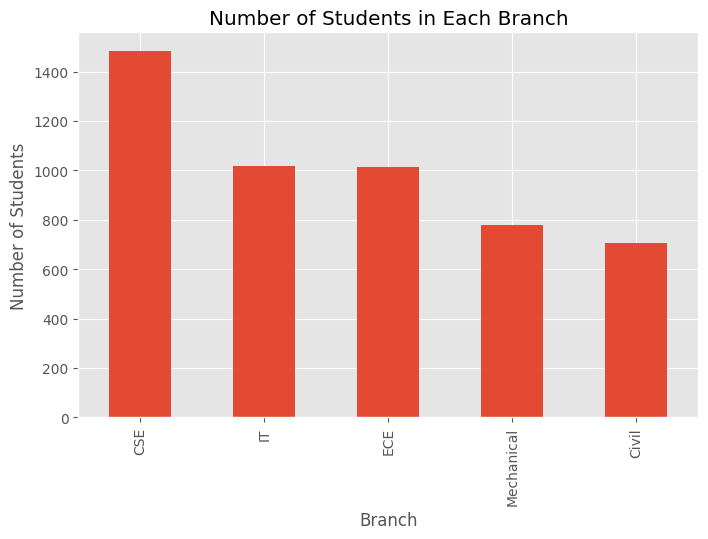

In [13]:
# Student Distribution by Branch

branch_counts = df["Branch"].value_counts()

plt.figure(figsize=(8,5))
branch_counts.plot(kind="bar")

plt.title("Number of Students in Each Branch")
plt.xlabel("Branch")
plt.ylabel("Number of Students")

plt.show()

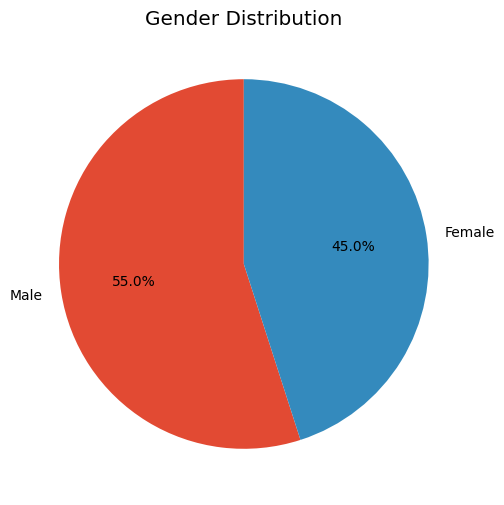

In [14]:
gender_counts = df["Gender"].value_counts()

plt.figure(figsize=(6,6))
plt.pie(
    gender_counts,
    labels=gender_counts.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Gender Distribution")
plt.show()

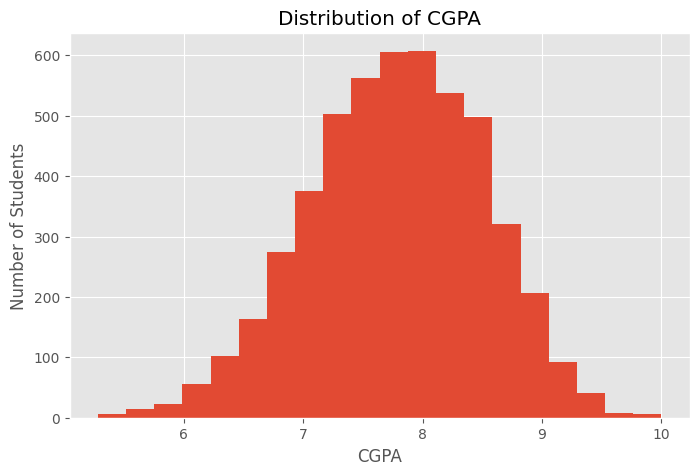

In [15]:
plt.figure(figsize=(8,5))

plt.hist(df["CGPA"], bins=20)

plt.title("Distribution of CGPA")
plt.xlabel("CGPA")
plt.ylabel("Number of Students")

plt.show()

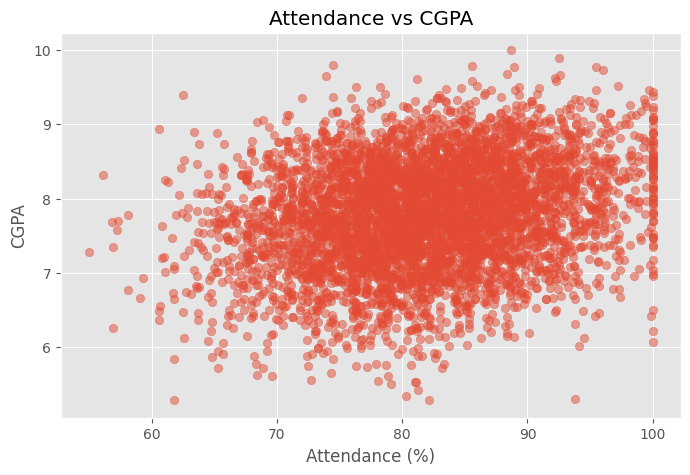

In [16]:
plt.figure(figsize=(8,5))

plt.scatter(df["Attendance"], df["CGPA"], alpha=0.5)

plt.title("Attendance vs CGPA")
plt.xlabel("Attendance (%)")
plt.ylabel("CGPA")

plt.show()

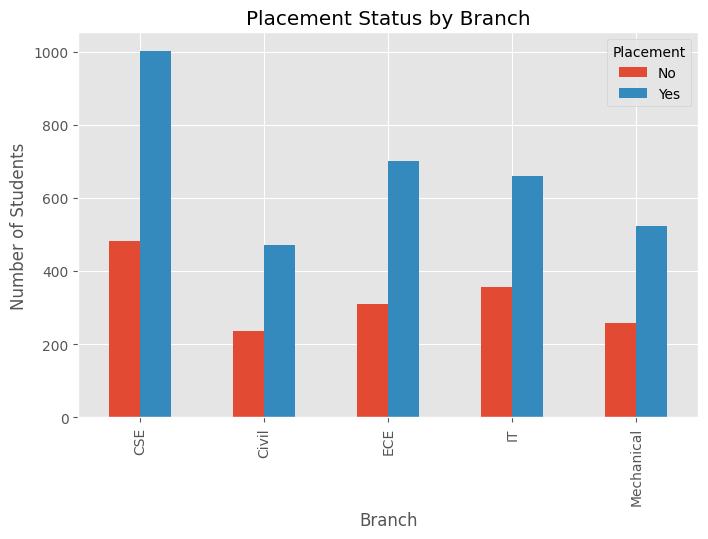

In [17]:
placement_branch = pd.crosstab(df["Branch"], df["Placement"])

placement_branch.plot(kind="bar", figsize=(8,5))

plt.title("Placement Status by Branch")
plt.xlabel("Branch")
plt.ylabel("Number of Students")

plt.show()

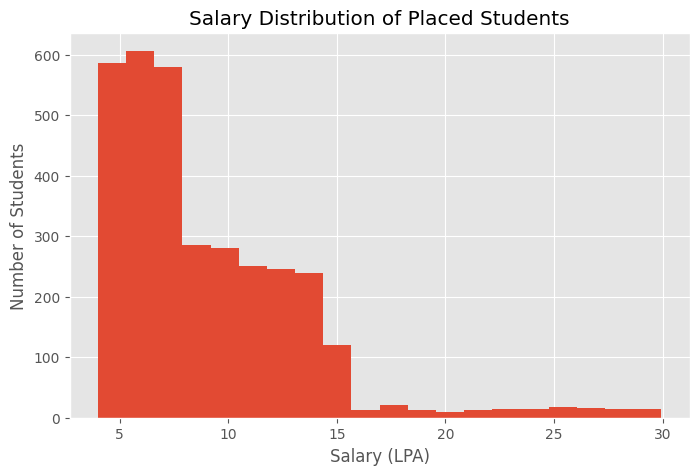

In [18]:
plt.figure(figsize=(8,5))

plt.hist(df[df["Salary_LPA"] > 0]["Salary_LPA"], bins=20)

plt.title("Salary Distribution of Placed Students")
plt.xlabel("Salary (LPA)")
plt.ylabel("Number of Students")

plt.show()

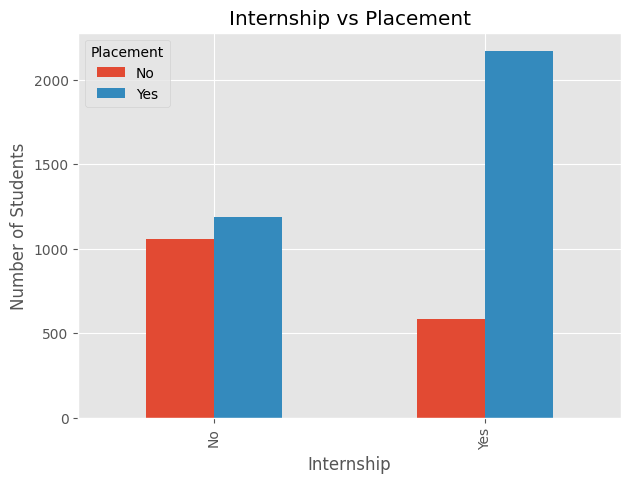

In [19]:
internship_placement = pd.crosstab(df["Internship"], df["Placement"])

internship_placement.plot(kind="bar", figsize=(7,5))

plt.title("Internship vs Placement")
plt.xlabel("Internship")
plt.ylabel("Number of Students")

plt.show()

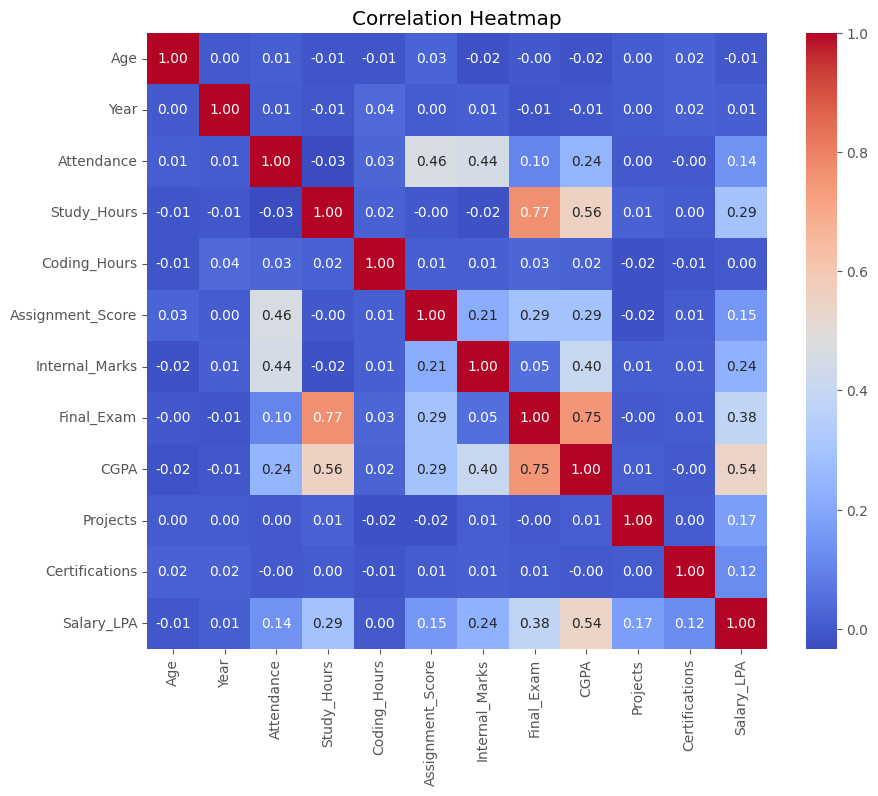

In [20]:
plt.figure(figsize=(10,8))

numeric_df = df.select_dtypes(include=np.number)

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.show()

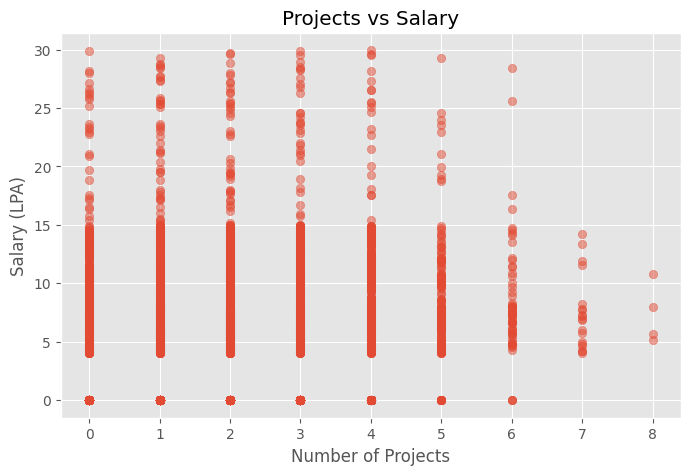

In [21]:
plt.figure(figsize=(8,5))

plt.scatter(df["Projects"], df["Salary_LPA"], alpha=0.5)

plt.title("Projects vs Salary")
plt.xlabel("Number of Projects")
plt.ylabel("Salary (LPA)")

plt.show()

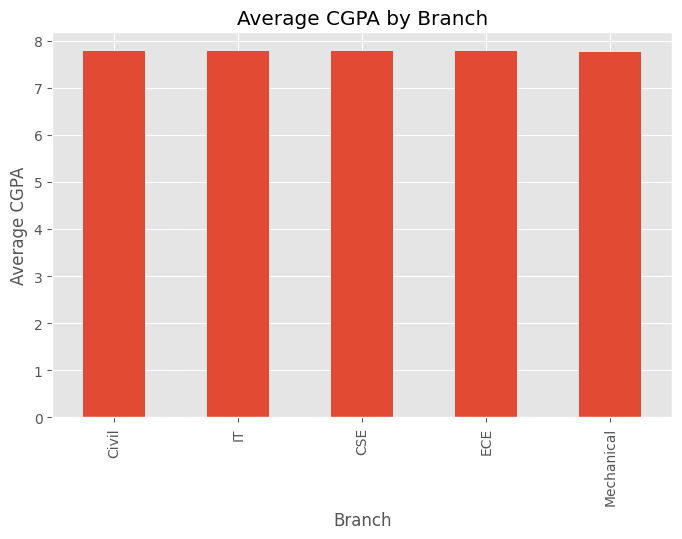

In [22]:
avg_cgpa = df.groupby("Branch")["CGPA"].mean().sort_values(ascending=False)

plt.figure(figsize=(8,5))
avg_cgpa.plot(kind="bar")

plt.title("Average CGPA by Branch")
plt.xlabel("Branch")
plt.ylabel("Average CGPA")

plt.show()

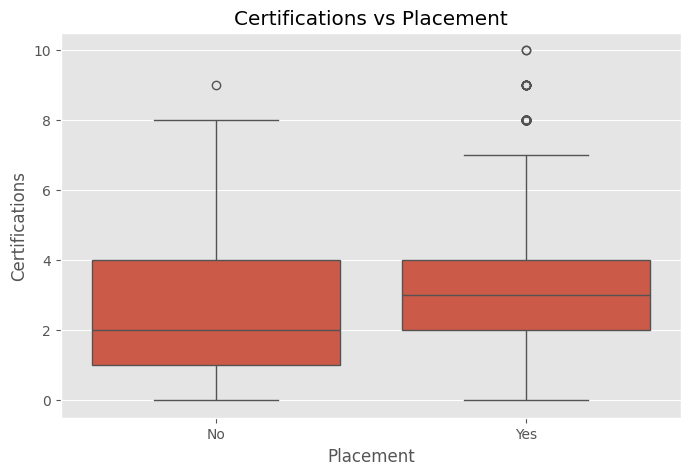

In [23]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="Placement",
    y="Certifications"
)

plt.title("Certifications vs Placement")

plt.show()

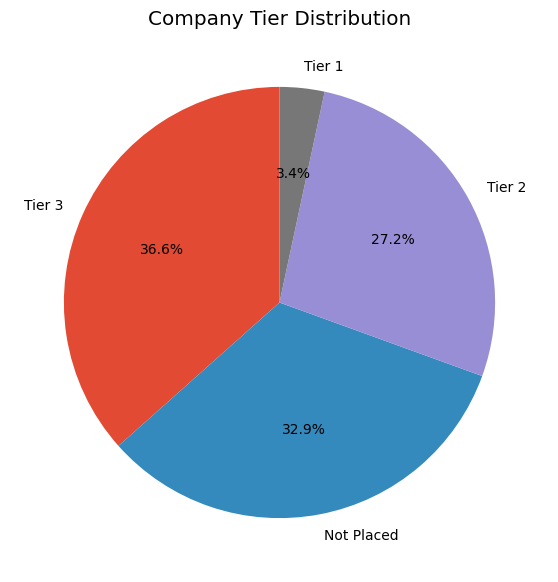

In [24]:
tier_counts = df["Company_Tier"].value_counts()

plt.figure(figsize=(7,7))

plt.pie(
    tier_counts,
    labels=tier_counts.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Company Tier Distribution")

plt.show()

# Final Business Insights

1. CSE has the highest student population among all branches.

2. Students with higher attendance generally achieve better CGPAs.

3. Study hours positively influence final exam performance.

4. Internship experience is associated with higher placement rates.

5. Students with more projects tend to receive better salary packages.

6. Most salary offers fall between 4–15 LPA.

7. Certifications contribute positively to placement opportunities.

8. Academic performance alone does not determine placement—projects, internships, and certifications also play important roles.

9. The correlation analysis shows strong relationships between attendance, marks, and CGPA.

10. Data-driven student analytics can help institutions identify areas where students may benefit from additional support and career preparation.

# 📌 Conclusion

This analysis indicates that attendance, internships, projects, and certifications are associated with better academic and placement outcomes.

The project demonstrates how data analytics can uncover meaningful patterns that may help educational institutions improve student success and career readiness.